In [1]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt


In [2]:
IMAGE_SIZE = 256
BATCH_SIZE =32
CHANNELS =3
EPOCHS = 30

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "plantvillage",
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)


Found 2152 files belonging to 3 classes.


In [4]:
len(dataset)

68

In [5]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

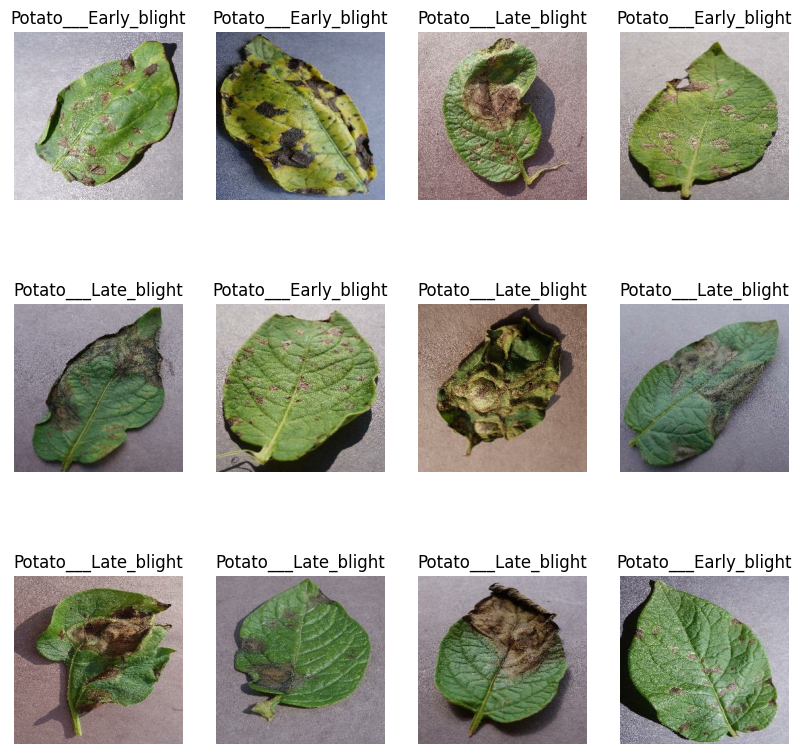

In [6]:
plt.figure(figsize = (10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])
        plt.axis("off")

In [7]:
len(dataset)*0.8

54.400000000000006

In [8]:
train_ds  = dataset.take(54)
test_ds = dataset.skip(54)

In [9]:
len(test_ds)

14

In [10]:
val_size = 0.1
len(dataset)*val_size 

6.800000000000001

In [11]:
val_ds = test_ds.take(6)
test_ds = test_ds.skip(6)

In [12]:
def get_dataset_partitions(ds,train_split=0.8,test_split=0.1,val_split=0.1, suffle = True,suffle_size=1000):
    ds_size = len(ds)
    if suffle:
        ds = ds.shuffle(suffle_size,seed=12)
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds,test_ds,val_ds
        

In [13]:
train_ds,val_ds,test_ds = get_dataset_partitions(dataset)

In [14]:
len(train_ds)

54

In [15]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds  = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [16]:
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    tf.keras.layers.Rescaling(1./255)
])

In [17]:
data_argmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [18]:
input_shape = (BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes =3
model = tf.keras.Sequential([
    resize_and_rescale,
    data_argmentation,
    layers.Conv2D(32,(3,3),activation = 'relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation = 'relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation = 'relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation = 'relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation = 'relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation = 'relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax')
])

model.build(input_shape = input_shape)

C:\Users\sssri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['accuracy']
)

In [21]:
history = model.fit(train_ds,
         validation_data = val_ds,
         batch_size = BATCH_SIZE,
         verbose=1,
         epochs = EPOCHS)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.4803 - loss: 0.9183 - val_accuracy: 0.5000 - val_loss: 0.8808
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.5625 - loss: 0.8390 - val_accuracy: 0.6944 - val_loss: 0.7410
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.7106 - loss: 0.6244 - val_accuracy: 0.7170 - val_loss: 0.6005
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.8021 - loss: 0.4456 - val_accuracy: 0.8779 - val_loss: 0.3065
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8675 - loss: 0.3261 - val_accuracy: 0.9126 - val_loss: 0.2336
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9068 - loss: 0.2379 - val_accuracy: 0.8912 - val_loss: 0.2648
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.9196 - loss: 0.1991 - val_accuracy: 0.9172 - val_loss: 0.1964
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9201 - loss: 0.2034 - val_accuracy: 0.8808 - val_

In [22]:
history.history.keys()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

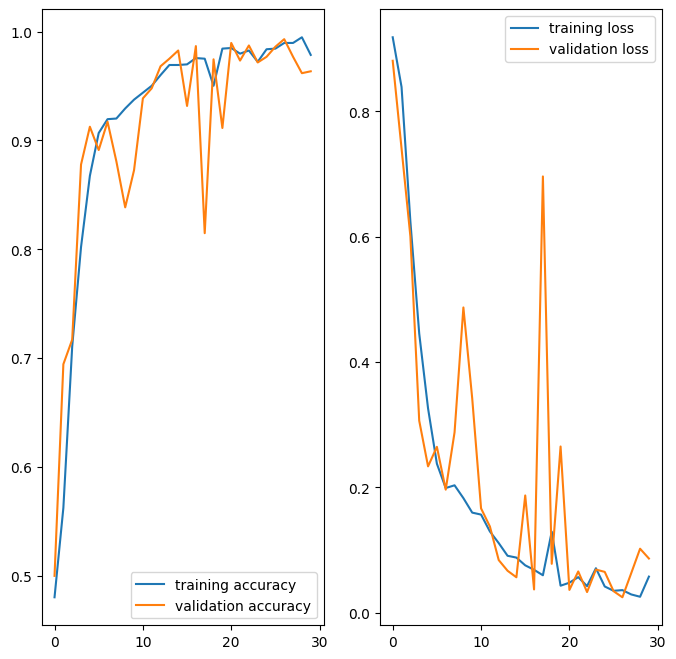

In [23]:
plt.figure(figsize = (8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label = 'training accuracy')
plt.plot(range(EPOCHS),val_acc,label = 'validation accuracy')
plt.legend(loc = 'lower right')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label = 'training loss')
plt.plot(range(EPOCHS),val_loss,label = 'validation loss')
plt.legend(loc = 'upper right')
plt.show()


first image to predict
actual label : Potato___Early_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 685ms/step
predicted label:  Potato___Early_blight


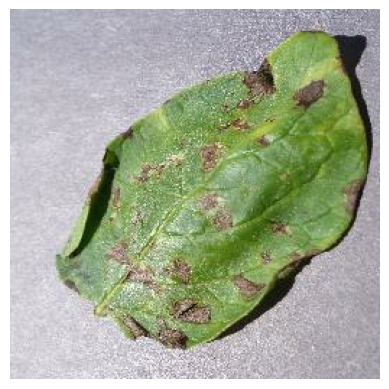

In [24]:
import numpy as np
for images_batch,labels_batch in test_ds.take(1):

    first_image = image_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()


    print("first image to predict")
    plt.imshow(first_image)
    plt.axis("off")
    print("actual label :",class_names[first_label])

    batch_prediction = model.predict(images_batch)
    print("predicted label: ",class_names[np.argmax(batch_prediction[0])])

In [25]:
def predict(model,image):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array,0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100*(np.max(predictions[0])),2)
    
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


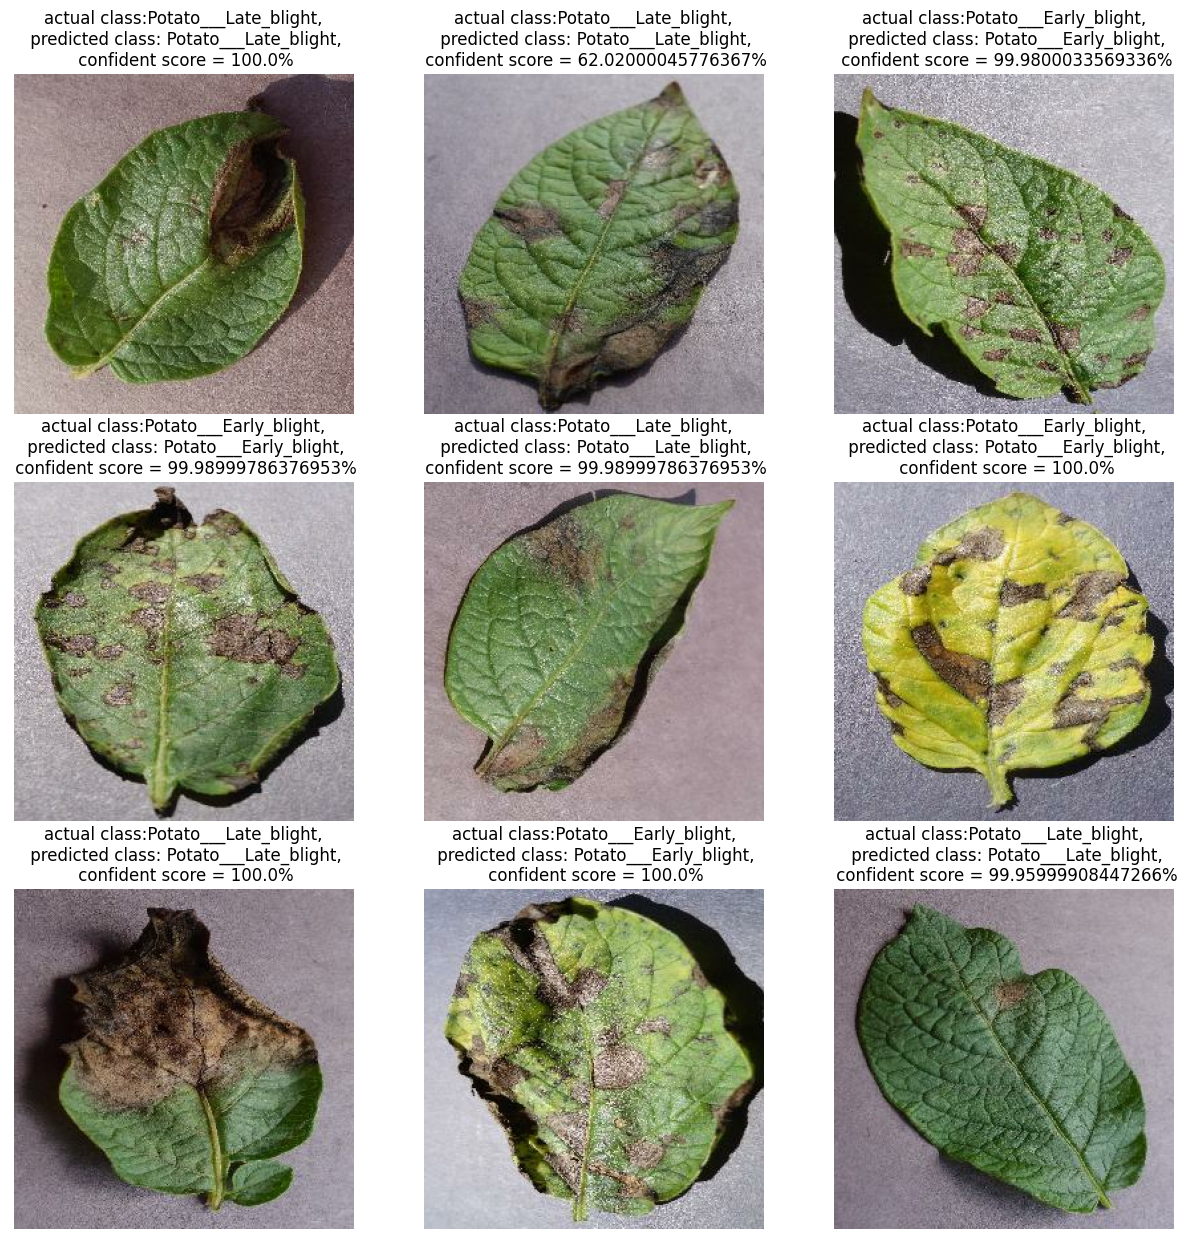

In [26]:
plt.figure(figsize=(15,15))
for images,labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        predicted_class,confidence = predict(model,images[i].numpy())
        actual_classes = class_names[labels[i]]

        plt.title(f"actual class:{actual_classes},\n predicted class: {predicted_class},\n confident score = {confidence}%")
        plt.axis('off')

In [27]:
# Load your keras model
model = tf.keras.models.load_model("../models/1.keras")

# Save in TF Serving format (creates a folder called 1)
model.export("../models/potatoes_model/1")

In [1]:
import tensorflow as tf

# Load your already trained model
model = tf.keras.models.load_model("../models/1.keras")

# Export for TF Serving
model.export("../models/potatoes_model/1")

INFO:tensorflow:Assets written to: ../models/potatoes_model/1\assets


INFO:tensorflow:Assets written to: ../models/potatoes_model/1\assets


Saved artifact at '../models/potatoes_model/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2161509828176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161509828752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161509830480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161509831056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161509831632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161509831440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161509832208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161509832400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161509830288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161509832016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2161509833552: TensorSpec